In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Test paths and display labels
TESTS = {
    'test_1': 'zero-shot (labels)',
    'test_2': 'zero-shot (descriptions)',
    'test_3': 'few-shot (labels)',
}

DATASETS = ['ArtDL', 'ICONCLASS', 'wikidata']

# Model families: each maps model folder name -> display label
MODEL_FAMILIES = {
    'Gemini Flash': {
        'gemini-2.5-flash-preview-05-20': 'Gemini 2.5 Flash\n(2025)',
        'gemini-3-flash-preview':         'Gemini 3 Flash\n(2026)',
    },
    'Gemini Pro': {
        'gemini-2.5-pro-preview-05-06': 'Gemini 2.5 Pro\n(2025)',
        'gemini-3.1-pro-preview':       'Gemini 3.1 Pro\n(2026)',
    },
    'GPT Mini': {
        'gpt-4o-mini-2024-07-18': 'GPT-4o mini\n(2024)',
        'gpt-5-mini-2025-08-07':  'GPT-5 mini\n(2025)',
    },
    'GPT Full': {
        'gpt-4o-2024-08-06':   'GPT-4o\n(2024)',
        'gpt-5.2-2025-12-11':  'GPT-5.2\n(2025)',
    },
}

TEST_COLORS = {
    'test_1': '#1f77b4',
    'test_2': '#ff7f0e',
    'test_3': '#2ca02c',
}


def load_accuracy(test_path, dataset, model_name):
    """Return accuracy as a float (0-1) or None if not available."""
    csv = os.path.join(test_path, dataset, model_name, 'summary_metrics.csv')
    if not os.path.exists(csv):
        return None
    df = pd.read_csv(csv)
    rows = df.loc[df['Model'] == model_name, 'Accuracy']
    if rows.empty:
        return None
    val = rows.values[0]
    if isinstance(val, str):
        return float(val.rstrip('%')) / 100.0
    return float(val)


def collect_data():
    """
    Returns a nested dict:
        data[dataset][family_name][test_key] = list of (x_label, accuracy) pairs
    """
    data = {}
    for dataset in DATASETS:
        data[dataset] = {}
        for family_name, models in MODEL_FAMILIES.items():
            data[dataset][family_name] = {}
            for test_key in TESTS:
                points = []
                for model_id, x_label in models.items():
                    acc = load_accuracy(test_key, dataset, model_id)
                    points.append((x_label, acc))
                data[dataset][family_name][test_key] = points
    return data


data = collect_data()
print('Data loaded.')

Data loaded.


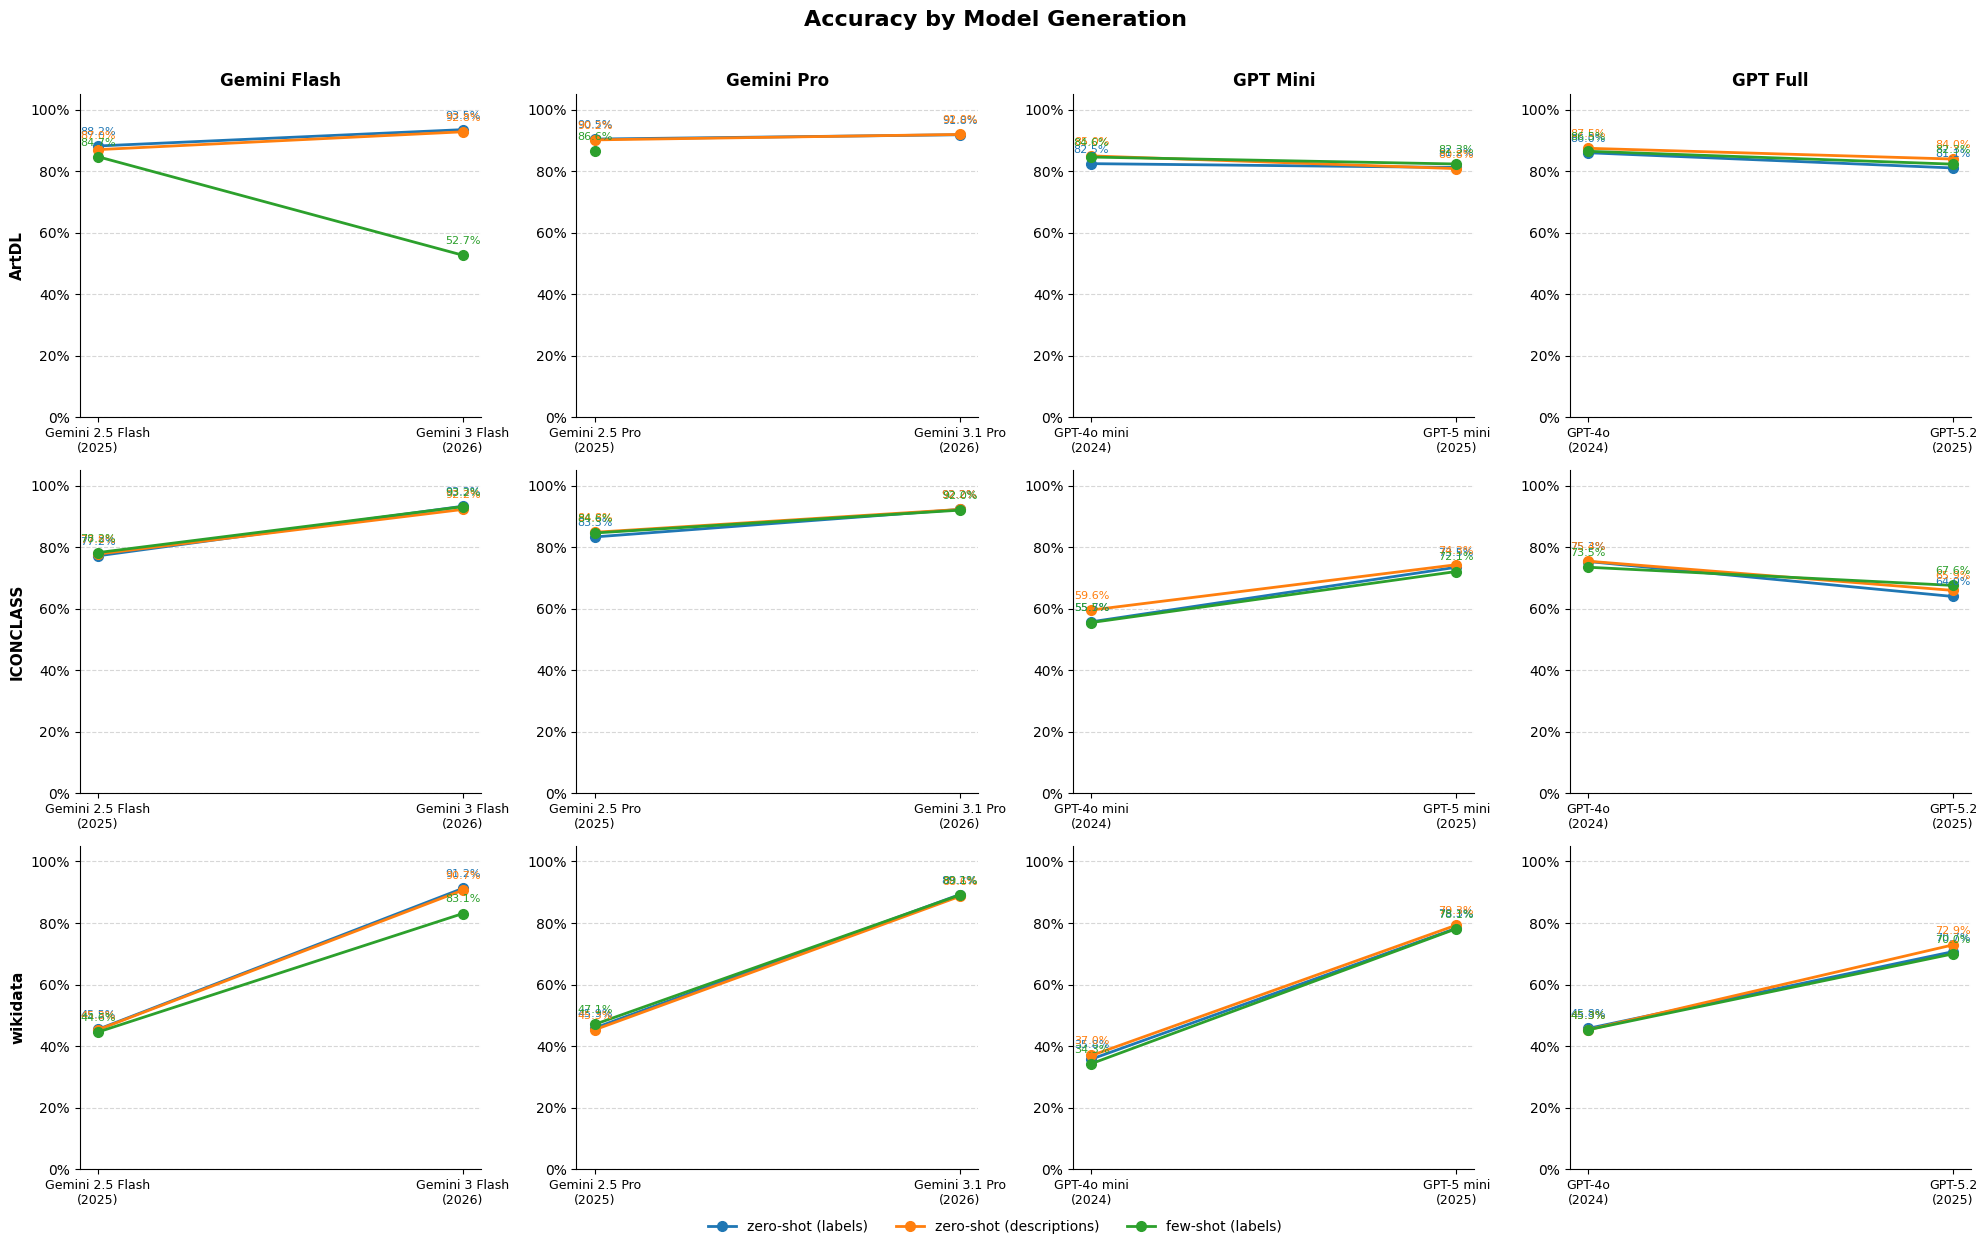

Saved to generation_compare.png


In [2]:
# Generation comparison: line plots
# Layout: rows = datasets, columns = model families

n_rows = len(DATASETS)
n_cols = len(MODEL_FAMILIES)
family_names = list(MODEL_FAMILIES.keys())

fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(5 * n_cols, 4 * n_rows),
    sharey=False,
)
fig.suptitle('Accuracy by Model Generation', fontsize=16, fontweight='bold', y=1.01)

for row_idx, dataset in enumerate(DATASETS):
    for col_idx, family_name in enumerate(family_names):
        ax = axes[row_idx][col_idx]
        family_data = data[dataset][family_name]

        x_labels = [pt[0] for pt in next(iter(family_data.values()))]
        x_pos = list(range(len(x_labels)))

        for test_key, test_label in TESTS.items():
            points = family_data[test_key]
            y_vals = [pt[1] for pt in points]

            # Draw only where data exists
            valid_x = [x_pos[i] for i, v in enumerate(y_vals) if v is not None]
            valid_y = [v for v in y_vals if v is not None]

            if valid_x:
                ax.plot(
                    valid_x, valid_y,
                    marker='o', linewidth=2, markersize=7,
                    color=TEST_COLORS[test_key],
                    label=test_label,
                )
                # Annotate each point with its value
                for xi, yi in zip(valid_x, valid_y):
                    ax.annotate(
                        f'{yi:.1%}',
                        (xi, yi),
                        textcoords='offset points',
                        xytext=(0, 8),
                        ha='center',
                        fontsize=8,
                        color=TEST_COLORS[test_key],
                    )

        ax.set_xticks(x_pos)
        ax.set_xticklabels(x_labels, fontsize=9)
        ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
        ax.set_ylim(0, 1.05)
        ax.grid(axis='y', linestyle='--', alpha=0.5)
        ax.spines[['top', 'right']].set_visible(False)

        # Titles
        if row_idx == 0:
            ax.set_title(family_name, fontsize=12, fontweight='bold')
        if col_idx == 0:
            ax.set_ylabel(dataset, fontsize=11, fontweight='bold')

# Single shared legend below the figure
handles, labels = axes[0][0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    loc='lower center',
    ncol=len(TESTS),
    fontsize=10,
    frameon=False,
    bbox_to_anchor=(0.5, -0.02),
)

plt.tight_layout()
plt.savefig('generation_compare.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved to generation_compare.png')